In [2]:
import pandas as pd
import json
from pathlib import Path
from matplotlib import pyplot as plt
import numpy as np
from collections import Counter
from scipy.spatial import distance 
from scipy.special import softmax
from scipy.stats import wasserstein_distance
import torch.nn.functional as F

## Useful Functions

In [3]:
def load_ndjson(data_path) -> list[dict]:

    """
    Loads ndjson files into memory as dictionaries.
    :param data_path: path to ndjson file
    :return: list of dictionaries
    """

    data = []
    with open(data_path, "r") as f:
        for line in f:
            if line.strip():  # avoid empty lines
                data.append(json.loads(line))

    return data

In [4]:
def get_internal_probs(measurements: list[dict]):
    
    """
    :param measurements: list of Measurement objects (or equivelant dictionaries)
    """
    
    # calculate probs from mean logits (should be all the same, though)
    internal_probs = softmax(np.mean([np.array(l['logits']) for l in measurements], axis=0))
    
    return internal_probs

In [60]:
def get_generation_probs(measurements: list[dict],
                        verbose: bool = False):
    
    """
    
    :param measurements: list of Measurement objects (or equivelant dictionaries)
    """
    # pronoun set is determined by the first measurement
    pnouns = measurements[0]['context']['pronouns_2']
    
    # calculate empirical generation probabilities (remove anything not in the list of pronouns)
    generated_pnouns = []
    for m in measurements:
        try:
            generated_pnouns.append(m['measurement']['BLANK'])
        except Exception as e:
            if verbose:
                print(f"The error: {e}\nwas thrown for item {m}")
            else:
                pass
    generation_counter = Counter(generated_pnouns)
    generation_counter_clean = {k: generation_counter[k] for k in pnouns}
    num_valid_measurements = np.sum(list(generation_counter_clean.values()))
    generation_probs = np.array(list(generation_counter_clean.values()))/num_valid_measurements
    
    return generation_probs

In [6]:
def get_generation_logit_distortion(measurements: list[dict]):
    
    """
    Measure of the difference between the (deterministic) internal beliefs of a model and the (observed) generation
    frequency of those same tokens. 
    
    Distance is measured as L1 (Manhattan) Distance because this a discrete, unordered distribution.
    
    :param measurements: list of Measurement objects (or equivelant dictionaries)
    """
    
    internal_probs = get_internal_probs(measurements)
    generation_probs = get_generation_probs(measurements)
    
    # L1 distance of the two arrays 
    return distance.cityblock(internal_probs, generation_probs)

In [313]:
def get_index(index: int,
              data: list[dict] | list[dict],
              filter_none: bool= True) -> list[dict] | list[dict]:
    """
    Filters list of Measurements (or equivalent dictionaries) by index.

    :param index: index of measurement to return
    :param data: list of Measurements
    :param filter_none: whether to filter out instances with erroneous responses
    :return: list of Measurements
    """

    all_measurements = [d for d in data if d['index'] == index]

    if filter_none:
        string_only = [d for d in all_measurements if isinstance(d['measurement']['BLANK'], str)]
        no_none = [d for d in string_only if d['measurement']['BLANK'] != "None"]
        return no_none
    else:
        return all_measurements


## Data Loading

In [182]:
DATA_DIR = Path("/data_users1/sagar/winogender_contextuality/data/interim")

In [183]:
LLAMA32_PATH = DATA_DIR / "one_pronoun_measurements_Llama-3.2-1B-Instruct_0.503.ndjson"
llama32 = load_ndjson(LLAMA32_PATH)
max_llama32 =max([d['index'] for d in llama32])

## Llama Testing

In [184]:
llama32[0], llama32[101]

({'index': 0,
  'context': {'sent_order': [0, 1],
   'pnoun_order': [None, 0],
   'sentence_1': None,
   'sentence_2': 'The technician told the customer that BLANK had completed the repair.',
   'pronouns_1': ['he', 'she'],
   'pronouns_2': ['he', 'she']},
  'measurement': {'BLANK': 'she'},
  'probabilities': None,
  'logits': [23.640625, 22.59375]},
 {'index': 0,
  'context': {'sent_order': [0, 1],
   'pnoun_order': [None, 0],
   'sentence_1': None,
   'sentence_2': 'The technician told the customer that BLANK had completed the repair.',
   'pronouns_1': ['he', 'she'],
   'pronouns_2': ['he', 'she']},
  'measurement': {'BLANK': 'he'},
  'probabilities': None,
  'logits': [23.640625, 22.59375]})

## Figures

For each item, there are two different sentences which get a blank filled in. Which one of the blanks is the one filled is determined by the sentence order. Sometimes, it is only the sentence by itself. There is also the free variable of what order the pronouns are presented in. Therefor, there are three binary free variables, or six degrees of freedom _for each sentence in each item_. 

1. Whether there is a contextual sentence.
2. What is the order of the pronouns presented as options. 
3. If there is a contextual sentence, what the pronoun in that sentence is. 

We want to know how logits and generation probs vary with pronoun orders, with the addition of the contextual sentence, and with the pronoun in the contextual sentence. 

We also want to know how logits and generation probs vary.

It could additionally be interesting to consider what the whole logit span looks like and maybe even how many instances the model failed to answer correctly, backing up the idea that some of these contexts are "hard".

Additionally maybe interesting to look at how this varies between RP and not. 

In [185]:
# First we get a partition
def get_index(index: int,
              data: list[dict]) -> list[dict]:
    
    """
    """
    
    return [d for d in data if d['index']==index]

def get_sent_order(order: list[int],
                   data: list[dict]) -> list[dict]:
    
    """
    """
    
    return [d for d in data if d['context']['sent_order'] == order]

def get_single_sentences(data: list[dict]) -> list[dict]:
    
    """
    """
    
    return [d for d in data if d['context']['sentence_1'] == None]

def get_filled_pnoun(pnoun_index: str, 
                     data: list[dict]) -> list[dict]:
    """
    """
    
    return [d for d in data if d['context']['pnoun_order'][0] == d['context']['pronouns_1'][pnoun_index]]

def get_pnoun_order(pnoun_order_index: int, 
                    data: list[dict]) -> list[dict]:
    
    """
    """
    
    return [d for d in data if d['context']['pnoun_order'][1] == pnoun_order_index]

In [186]:
test_data = get_single_sentences(get_sent_order([1,0], get_index(11, llama32)))
test_data

[{'index': 11,
  'context': {'sent_order': [1, 0],
   'pnoun_order': [None, 0],
   'sentence_1': None,
   'sentence_2': 'The teenager confided in the therapist because BLANK seemed trustworthy.',
   'pronouns_1': ['he', 'she'],
   'pronouns_2': ['he', 'she']},
  'measurement': {'BLANK': 'he'},
  'probabilities': None,
  'logits': [22.046875, 22.328125]},
 {'index': 11,
  'context': {'sent_order': [1, 0],
   'pnoun_order': [None, 0],
   'sentence_1': None,
   'sentence_2': 'The teenager confided in the therapist because BLANK seemed trustworthy.',
   'pronouns_1': ['he', 'she'],
   'pronouns_2': ['he', 'she']},
  'measurement': {'BLANK': 'she'},
  'probabilities': None,
  'logits': [22.046875, 22.328125]},
 {'index': 11,
  'context': {'sent_order': [1, 0],
   'pnoun_order': [None, 0],
   'sentence_1': None,
   'sentence_2': 'The teenager confided in the therapist because BLANK seemed trustworthy.',
   'pronouns_1': ['he', 'she'],
   'pronouns_2': ['he', 'she']},
  'measurement': {'BLANK

In [187]:
get_generation_probs(test_data), get_internal_probs(test_data), get_generation_logit_distortion(test_data)

(array([0.1975, 0.8025]),
 array([0.26588047, 0.73411953]),
 np.float64(0.13676094619963386))

Text(0, 0.5, 'Empirical Generation Probability')

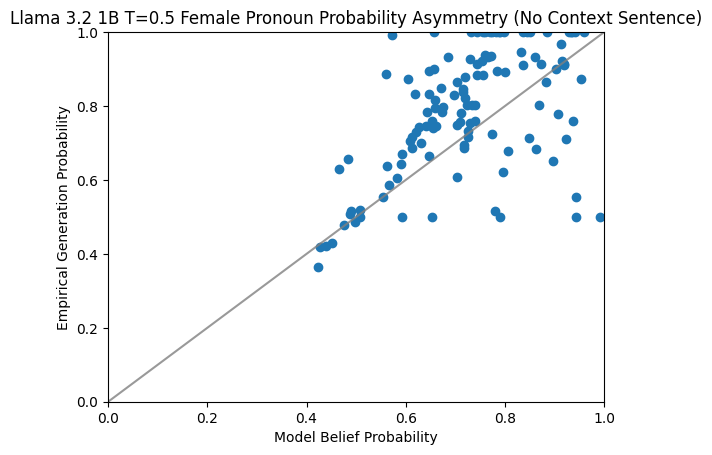

In [190]:
internal_generated_llama32 = []
for idx in range(max_llama32):
    d1 = get_single_sentences(get_sent_order([0,1], get_index(idx, llama32)))
    d2 = get_single_sentences(get_sent_order([1,0], get_index(idx, llama32)))
    
    internal_generated_llama32.append((get_internal_probs(d1)[1], get_generation_probs(d1)[1]))
    internal_generated_llama32.append((get_internal_probs(d2)[1], get_generation_probs(d2)[1]))
    
plt.scatter([i[0] for i in internal_generated_llama32], 
           [i[1] for i in internal_generated_llama32])
plt.plot(np.linspace(0,1,20), np.linspace(0,1,20), color='gray', alpha=0.8)

plt.ylim(0,1)
plt.xlim(0,1)
plt.title('Llama 3.2 1B T=0.5 Female Pronoun Probability Asymmetry (No Context Sentence)')
plt.xlabel('Model Belief Probability')
plt.ylabel('Empirical Generation Probability')

Text(0.5, 1.0, 'Distance Distribution Llama 3.2 1B')

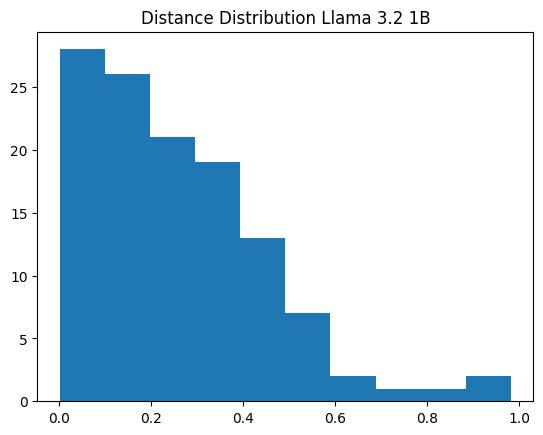

In [191]:
probability_distance_llama32 = []
for idx in range(max_llama32):
    d1 = get_single_sentences(get_sent_order([0,1], get_index(idx, llama32)))
    d2 = get_single_sentences(get_sent_order([1,0], get_index(idx, llama32)))
    
    probability_distance_llama32.append(get_generation_logit_distortion(d1))
    probability_distance_llama32.append(get_generation_logit_distortion(d2))
    
plt.hist(probability_distance_llama32, bins=10)

plt.title('Distance Distribution Llama 3.2 1B')

(array([20., 20., 14., 13., 20., 12.,  9.,  9.,  1.,  2.]),
 array([0.00159698, 0.07066198, 0.13972698, 0.20879198, 0.27785698,
        0.34692198, 0.41598698, 0.48505198, 0.55411698, 0.62318198,
        0.69224698]),
 <BarContainer object of 10 artists>)

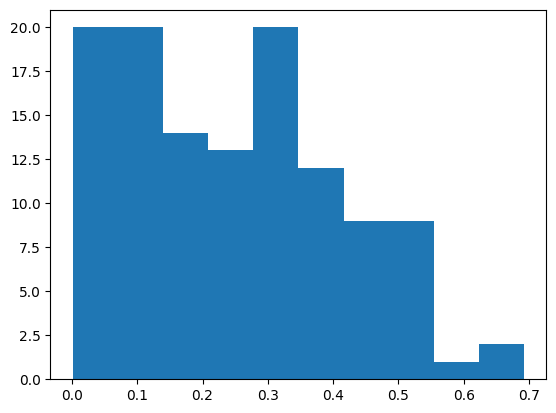

In [192]:
# Logit changes with context addition, m first
sent_orders = [[0,1], [1,0]]

llama_m_first_logit_changes = []
for idx in range(max_llama32):
    for order in sent_orders:
        none_sentence = get_single_sentences(get_sent_order(order, get_index(idx, llama32)))
        filled_sentence = get_filled_pnoun(0, get_sent_order(order, get_index(idx, llama32)))
        llama_m_first_logit_changes.append(distance.cityblock(
            get_internal_probs(none_sentence), 
            get_internal_probs(filled_sentence)))
        
plt.hist(llama_m_first_logit_changes, bins=10)

(array([20., 14., 20., 22., 21., 14.,  7.,  0.,  0.,  2.]),
 array([0.00656167, 0.17818727, 0.34981288, 0.52143848, 0.69306408,
        0.86468968, 1.03631529, 1.20794089, 1.37956649, 1.55119209,
        1.72281769]),
 <BarContainer object of 10 artists>)

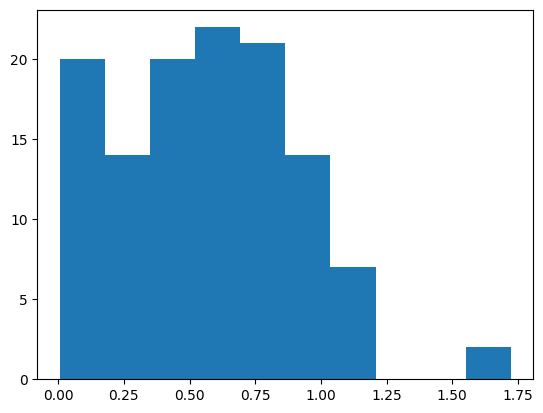

In [193]:
# Logit changes with context addition, m first
sent_orders = [[0,1], [1,0]]

llama_f_first_logit_changes = []
for idx in range(max_llama32):
    for order in sent_orders:
        none_sentence = get_single_sentences(get_sent_order(order, get_index(idx, llama32)))
        filled_sentence = get_filled_pnoun(1, get_sent_order(order, get_index(idx, llama32)))
        llama_f_first_logit_changes.append(distance.cityblock(
            get_internal_probs(none_sentence), 
            get_internal_probs(filled_sentence)))
        
plt.hist(llama_f_first_logit_changes, bins=10)

(0.0, 2.0)

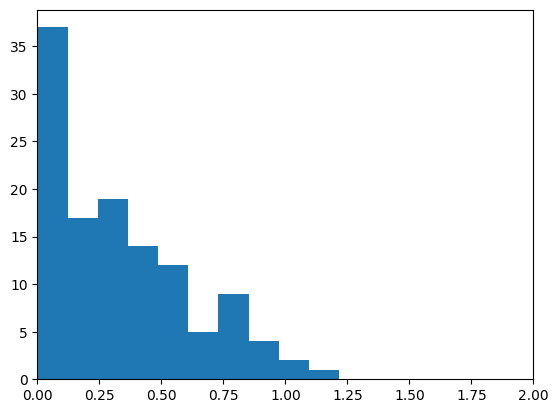

In [194]:
# Logit changes with context addition, m first
sent_orders = [[0,1], [1,0]]

llama_m_first_gen_changes = []
for idx in range(max_llama32):
    for order in sent_orders:
        none_sentence = get_single_sentences(get_sent_order(order, get_index(idx, llama32)))
        filled_sentence = get_filled_pnoun(0, get_sent_order(order, get_index(idx, llama32)))
        llama_m_first_gen_changes.append(distance.cityblock(
            get_generation_probs(none_sentence), 
            get_generation_probs(filled_sentence)))
        
plt.hist(llama_m_first_gen_changes, bins=10)
plt.xlim(0, 2)

/tmp/ipykernel_3224490/627583355.py:24: RuntimeWarning: invalid value encountered in divide
  generation_probs = np.array(list(generation_counter_clean.values()))/num_valid_measurements


(0.0, 2.0)

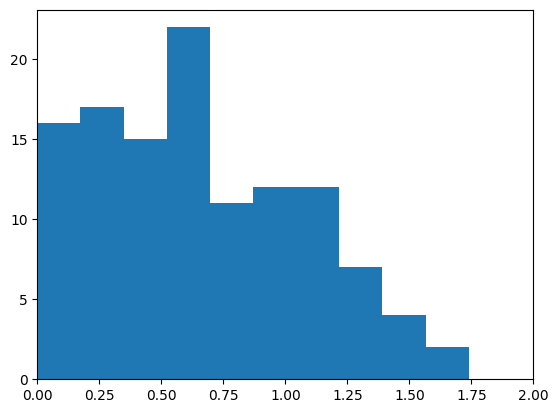

In [195]:
# Logit changes with context addition, m first
sent_orders = [[0,1], [1,0]]

llama_f_first_gen_changes = []
for idx in range(max_llama32):
    for order in sent_orders:
        none_sentence = get_single_sentences(get_sent_order(order, get_index(idx, llama32)))
        filled_sentence = get_filled_pnoun(1, get_sent_order(order, get_index(idx, llama32)))
        llama_f_first_gen_changes.append(distance.cityblock(
            get_generation_probs(none_sentence), 
            get_generation_probs(filled_sentence)))
        
plt.hist(llama_f_first_gen_changes, bins=10)
plt.xlim(0,2)

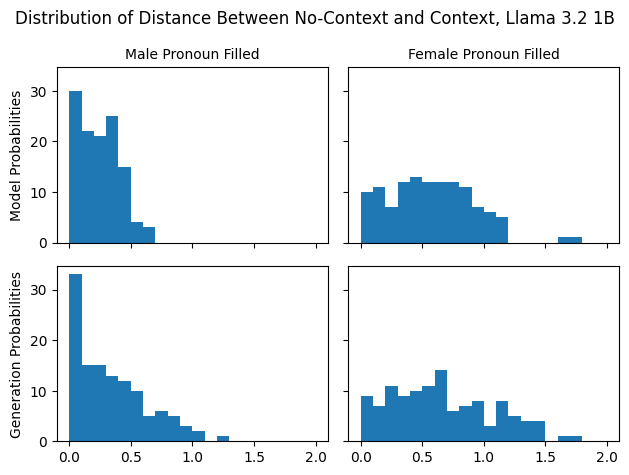

In [199]:
fig, axs = plt.subplots(2,2, sharey=True, sharex=True)
dist_bins = np.linspace(0,2,21)
axs[0,0].hist(llama_m_first_logit_changes, bins=dist_bins)
axs[0,1].hist(llama_f_first_logit_changes, bins=dist_bins)
axs[1,0].hist(llama_m_first_gen_changes, bins=dist_bins)
axs[1,1].hist(llama_f_first_gen_changes, bins=dist_bins)

axs[0,0].set_title('Male Pronoun Filled', fontsize=10)
axs[0,1].set_title('Female Pronoun Filled', fontsize=10)
axs[0,0].set_ylabel('Model Probabilities', )
axs[1,0].set_ylabel('Generation Probabilities')

fig.suptitle('Distribution of Distance Between No-Context and Context, Llama 3.2 1B')
plt.tight_layout()

Text(0.5, 1.0, 'Llama 3.2 1B Model Probabilities')

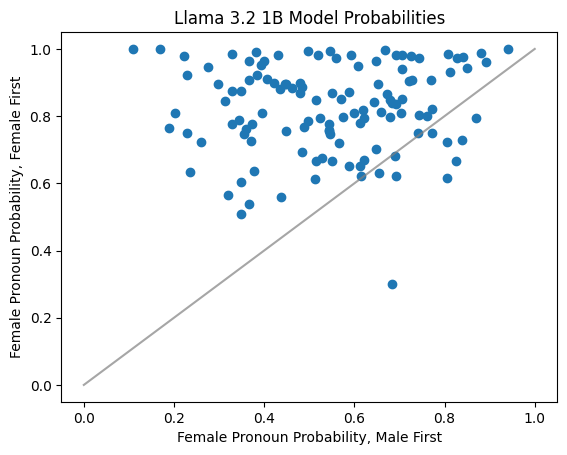

In [197]:
# Difference between forward and reverse pronoun order in unfilled sentences 

llama_fwd_none_model = []
llama_bwd_none_model = []

for idx in range(max_llama32):
    for order in sent_orders:
        fwd = get_pnoun_order(0, get_single_sentences(get_sent_order(order, get_index(idx, llama32))))
        bwd = get_pnoun_order(1, get_single_sentences(get_sent_order(order, get_index(idx, llama32))))
        
        
        llama_fwd_none_model.append(get_internal_probs(fwd)[1])
        llama_bwd_none_model.append(get_internal_probs(bwd)[1])
        
plt.scatter(llama_fwd_none_model, llama_bwd_none_model)
plt.plot(np.linspace(0,1,10), np.linspace(0,1,10), marker=None, color='gray', alpha=0.7)
plt.xlabel('Female Pronoun Probability, Male First')
plt.ylabel('Female Pronoun Probability, Female First')
plt.title('Llama 3.2 1B Model Probabilities')

/tmp/ipykernel_3224490/627583355.py:24: RuntimeWarning: invalid value encountered in divide
  generation_probs = np.array(list(generation_counter_clean.values()))/num_valid_measurements


Text(0.5, 1.0, 'Llama 3.2 1B Generation Probabilities')

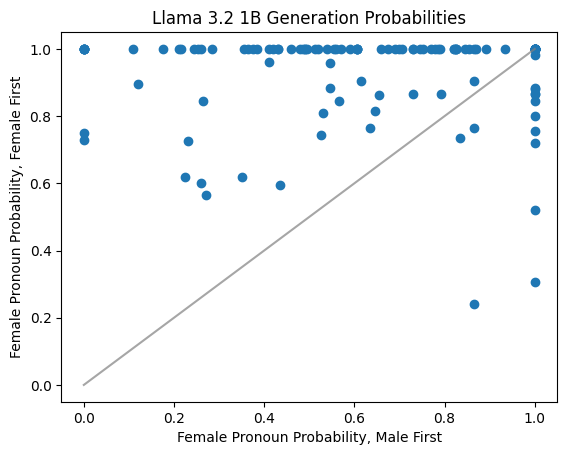

In [198]:
# Difference between forward and reverse pronoun order in unfilled sentences 

llama_fwd_none_gen = []
llama_bwd_none_gen = []

for idx in range(max_llama32):
    for order in sent_orders:
        fwd = get_pnoun_order(0, get_single_sentences(get_sent_order(order, get_index(idx, llama32))))
        bwd = get_pnoun_order(1, get_single_sentences(get_sent_order(order, get_index(idx, llama32))))
        
        llama_fwd_none_gen.append(get_generation_probs(fwd)[1])
        llama_bwd_none_gen.append(get_generation_probs(bwd)[1])
        
plt.scatter(llama_fwd_none_gen, llama_bwd_none_gen)
plt.plot(np.linspace(0,1,10), np.linspace(0,1,10), marker=None, color='gray', alpha=0.7)
plt.xlabel('Female Pronoun Probability, Male First')
plt.ylabel('Female Pronoun Probability, Female First')
plt.title('Llama 3.2 1B Generation Probabilities')

# Belief Contextuality

**Hold up** Can't I also get the probabilities for the first pronoun through the logits?? I guess I would run into the same issue regarding whether or not it would resolve the correct pronoun. 

In [301]:
# Super messy and unintuitive code, but should work

def cbd_expectation(px: float):

    """
    Returns the expectation value of a random variable, given its marginal probability (as per Dzhafarov)
    :param px: marginal probability
    :return: expectation value
    """
    return 2*px - 1

def cbd_correlation(px: float,
                    py: float,
                    pxy: float):
    """
    Returns the correlation of two random variables, given their marginals and joint (as per Dzhafarov)
    :param px: marginal probability of X
    :param py: marginal probability of Y
    :param pxy: joint probability
    :return:
    """
    return 4*pxy - 2*px - 2*py + 1


# Sentence-order contextuality via CBD
def sentence_order_results_internal(idx: int,
                                    model_measurements: list[dict],
                                    pnoun_order: list[int] = [0, 0],
                                    default_pronoun: int = 1  # 0 for male, 1 for female
                                   ) -> dict:
    """
    Creates a dictionary given a subset of measurements for a single pair of sentences which summarizes the results of
    all runs, separated on the basis of sentence order, filtered for only one pronoun order.

    :param idx: integer index sentence pair
    :param model_measurements: list of Measurement objects (or equivalently structured dictionaries)
    :param pnoun_order: filtered pronoun order--NOTE: this uses default_pronoun indexing 
    :param default_pronoun: pronoun index for probabiity calculations (default = 1 for female)
    :return:
    """
    sentence_measurements = get_index(idx, model_measurements)
    
    pnoun_filled_fwd = [sentence_measurements[0]['context']['pronouns_1'][pnoun_order[0]], pnoun_order[1]]
    pnoun_filled_bwd = [sentence_measurements[0]['context']['pronouns_2'][pnoun_order[0]], pnoun_order[1]]
    
    test_measurements = [d for d in sentence_measurements if d['context']['pnoun_order']==pnoun_filled_fwd or
                        d['context']['pnoun_order']==pnoun_filled_bwd]

    data_dict = {'forward': {'fixed_pnoun': [], 'free_pnoun': [], 'pronouns': []},
                 'reverse': {'fixed_pnoun': [], 'free_pnoun': [], 'pronouns': []}}

    for d in test_measurements:
        
        context = d['context']['sent_order'] 
            
        if context == [0, 1]:
            dict_key = 'forward'
            fixed_pnoun = d['context']['pnoun_order'][0]
            free_pnoun = d['logits']
            default_p1 = d['context']['pronouns_1'][default_pronoun]
            default_p2 = d['context']['pronouns_2'][default_pronoun]
        elif context == [1, 0]:
            dict_key = 'reverse'
            fixed_pnoun = d['context']['pnoun_order'][0]
            free_pnoun = d['logits']
            default_p1 = d['context']['pronouns_2'][default_pronoun]
            default_p2 = d['context']['pronouns_1'][default_pronoun]
        else:
            raise AttributeError

        data_dict[dict_key]['fixed_pnoun'].append(fixed_pnoun.lower())
        data_dict[dict_key]['free_pnoun'].append(free_pnoun)
        data_dict[dict_key]['pronouns'] = [default_p1, default_p2]

    return data_dict

def calculate_sentence_nc_fraction_internal(data_dict: dict) -> float:

    """
    Calculates noncontextual fraction based on the output from sentence_order_results()
    
    :param data_dict: output of sentence_order_results()
    :return: noncontextual fraction
    """
    C1_size = len(data_dict['forward']['fixed_pnoun'])
    C2_size = len(data_dict['reverse']['fixed_pnoun'])

    V1_dict = Counter(data_dict['forward']['fixed_pnoun'])
    W2 = softmax(np.mean(data_dict['forward']['free_pnoun'], axis=0))
    W1 = softmax(np.mean(data_dict['reverse']['free_pnoun'], axis=0))
    V2_dict = Counter(data_dict['reverse']['fixed_pnoun'])

    try:  
        target_f = data_dict['forward']['pronouns']
        target_r = data_dict['reverse']['pronouns']
        
    

        V1 = V1_dict.get(target_f[0], 0) / C1_size
        W2 = W2[1]
        W1 = W1[1]
        V2 = V2_dict.get(target_r[1], 0) / C2_size
        
    except IndexError:
        print((idx, data_dict))

    # Compute joint probabilities
    ## p(x,y) = p(y|x)p(x)
    forward_trials = zip(data_dict['forward']['fixed_pnoun'], data_dict['forward']['free_pnoun'])
    count_c1 = sum(1 for x, y in forward_trials if x == target_f[0] and y == target_f[1])
    V1W2 = count_c1 / C1_size

    reverse_trials = zip(data_dict['reverse']['fixed_pnoun'], data_dict['reverse']['free_pnoun'])
    count_c2 = sum(1 for x, y in reverse_trials if x == target_r[0] and y == target_r[1])
    V2W1 = count_c2 / C2_size

    delta_c = (
            abs(cbd_correlation(V1, V2, V1W2) - cbd_correlation(V2, W1, V2W1))
            - (abs(cbd_expectation(V1) - cbd_expectation(W1))
               + abs(cbd_expectation(V2) - cbd_expectation(W2)))
    )

    return delta_c

<BarContainer object of 60 artists>

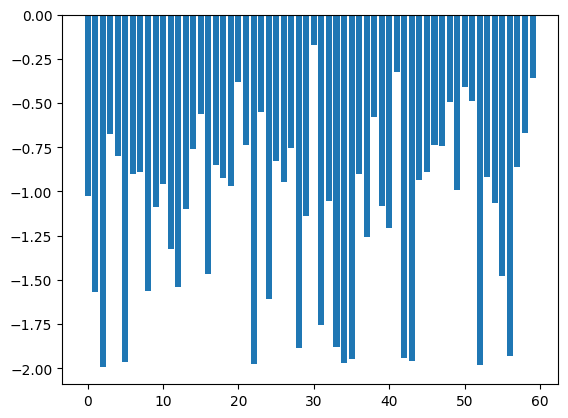

In [41]:
logit_00_contextuality = []
for idx in range(max_llama32):
    data_dict_idx = sentence_order_results_internal(idx, llama32)
    logit_00_contextuality.append(calculate_sentence_nc_fraction_internal(data_dict_idx))
plt.bar(range(max_llama32), logit_00_contextuality)

<BarContainer object of 60 artists>

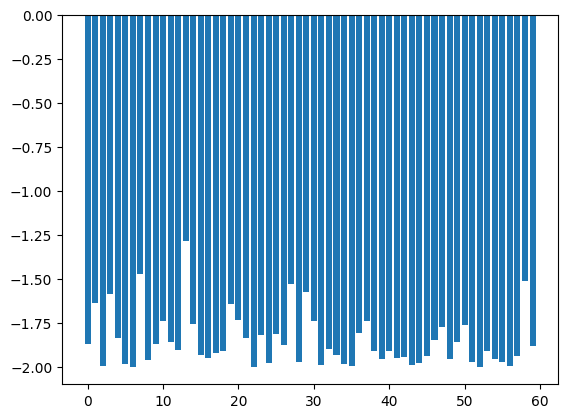

In [42]:
logit_01_contextuality = []
for idx in range(max_llama32):
    data_dict_idx = sentence_order_results_internal(idx, llama32, pnoun_order=[0,1])
    logit_01_contextuality.append(calculate_sentence_nc_fraction_internal(data_dict_idx))
plt.bar(range(max_llama32), logit_01_contextuality)

<BarContainer object of 60 artists>

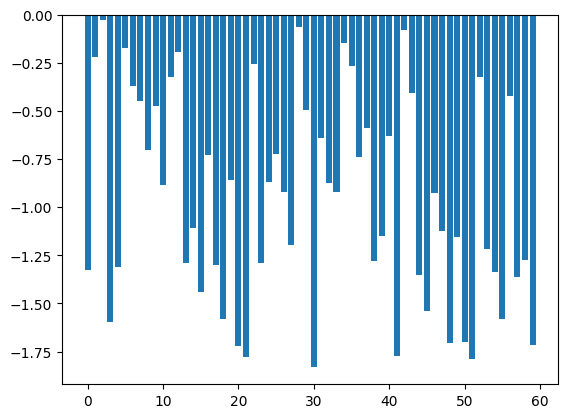

In [43]:
logit_10_contextuality = []
for idx in range(max_llama32):
    data_dict_idx = sentence_order_results_internal(idx, llama32, pnoun_order=[1,0])
    logit_10_contextuality.append(calculate_sentence_nc_fraction_internal(data_dict_idx))
plt.bar(range(max_llama32), logit_10_contextuality)

<BarContainer object of 60 artists>

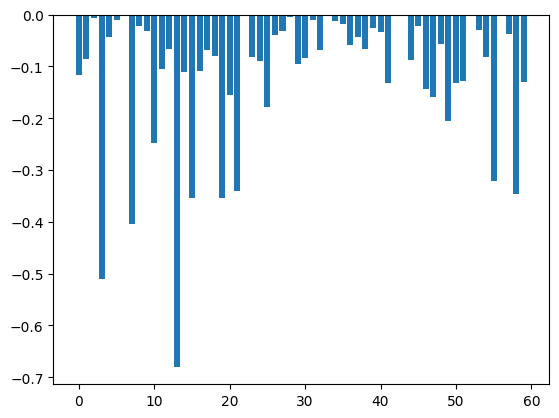

In [44]:
logit_11_contextuality = []
for idx in range(max_llama32):
    data_dict_idx = sentence_order_results_internal(idx, llama32, pnoun_order=[1,1])
    logit_11_contextuality.append(calculate_sentence_nc_fraction_internal(data_dict_idx))
plt.bar(range(max_llama32), logit_11_contextuality)

# Generation Fixed Pronoun 

In [314]:
# Sentence-order contextuality via CBD
def sentence_order_results_single_gen(idx: int,
                                    model_measurements: list[dict],
                                    pnoun_order: list[int] = [0, 0],
                                    default_pronoun: int = 1  # 0 for male, 1 for female
                                   ) -> dict:
    """
    Creates a dictionary given a subset of measurements for a single pair of sentences which summarizes the results of
    all runs, separated on the basis of sentence order, filtered for only one pronoun order.

    :param idx: integer index sentence pair
    :param model_measurements: list of Measurement objects (or equivalently structured dictionaries)
    :param pnoun_order: filtered pronoun order--NOTE: this uses default_pronoun indexing 
    :param default_pronoun: pronoun index for probabiity calculations (default = 1 for female)
    :return:
    """
    sentence_measurements = sentence_measurements = get_index(idx, model_measurements)
    
    pnoun_filled_fwd = [sentence_measurements[0]['context']['pronouns_1'][pnoun_order[0]], pnoun_order[1]]
    pnoun_filled_bwd = [sentence_measurements[0]['context']['pronouns_2'][pnoun_order[0]], pnoun_order[1]]
    
    test_measurements = [d for d in sentence_measurements if d['context']['pnoun_order']==pnoun_filled_fwd or
                        d['context']['pnoun_order']==pnoun_filled_bwd]

    data_dict = {'forward': {'fixed_pnoun': [], 'free_pnoun': [], 'pronouns': []},
                 'reverse': {'fixed_pnoun': [], 'free_pnoun': [], 'pronouns': []}}

    for d in test_measurements:
        
        context = d['context']['sent_order'] 
            
        if context == [0, 1]:
            dict_key = 'forward'
            fixed_pnoun = d['context']['pnoun_order'][0]
            free_pnoun = d['measurement']['BLANK']
            default_p1 = d['context']['pronouns_1'][default_pronoun]
            default_p2 = d['context']['pronouns_2'][default_pronoun]
        elif context == [1, 0]:
            dict_key = 'reverse'
            fixed_pnoun = d['context']['pnoun_order'][0]
            free_pnoun = d['measurement']['BLANK']
            default_p1 = d['context']['pronouns_2'][default_pronoun]
            default_p2 = d['context']['pronouns_1'][default_pronoun]
        else:
            raise AttributeError

        data_dict[dict_key]['fixed_pnoun'].append(fixed_pnoun.lower())
        data_dict[dict_key]['free_pnoun'].append(free_pnoun.lower())
        data_dict[dict_key]['pronouns'] = [default_p1, default_p2]

    return data_dict

def calculate_sentence_nc_fraction_single_gen(data_dict: dict) -> float:

    """
    Calculates noncontextual fraction based on the output from sentence_order_results()
    
    :param data_dict: output of sentence_order_results()
    :return: noncontextual fraction
    """
    C1_size = len(data_dict['forward']['fixed_pnoun'])
    C2_size = len(data_dict['reverse']['fixed_pnoun'])

    V1_dict = Counter(data_dict['forward']['fixed_pnoun'])
    W2_dict = Counter(data_dict['forward']['free_pnoun'])
    W1_dict = Counter(data_dict['reverse']['free_pnoun'])
    V2_dict = Counter(data_dict['reverse']['fixed_pnoun'])

    try:  
        target_f = data_dict['forward']['pronouns']
        target_r = data_dict['reverse']['pronouns']
        
    

        V1 = V1_dict.get(target_f[0], 0) / C1_size
        W2 = W2_dict.get(target_f[1], 0) / C1_size
        W1 = W1_dict.get(target_r[0], 0) / C2_size
        V2 = V2_dict.get(target_r[1], 0) / C2_size
        
    except IndexError:
        print((idx, data_dict))

    # Compute joint probabilities
    ## p(x,y) = p(y|x)p(x)
    forward_trials = zip(data_dict['forward']['fixed_pnoun'], data_dict['forward']['free_pnoun'])
    count_c1 = sum(1 for x, y in forward_trials if x == target_f[0] and y == target_f[1])
    V1W2 = count_c1 / C1_size

    reverse_trials = zip(data_dict['reverse']['fixed_pnoun'], data_dict['reverse']['free_pnoun'])
    count_c2 = sum(1 for x, y in reverse_trials if x == target_r[0] and y == target_r[1])
    V2W1 = count_c2 / C2_size

    delta_c = (
            abs(cbd_correlation(V1, V2, V1W2) - cbd_correlation(V2, W1, V2W1))
            - (abs(cbd_expectation(V1) - cbd_expectation(W1))
               + abs(cbd_expectation(V2) - cbd_expectation(W2)))
    )

    return delta_c

<BarContainer object of 60 artists>

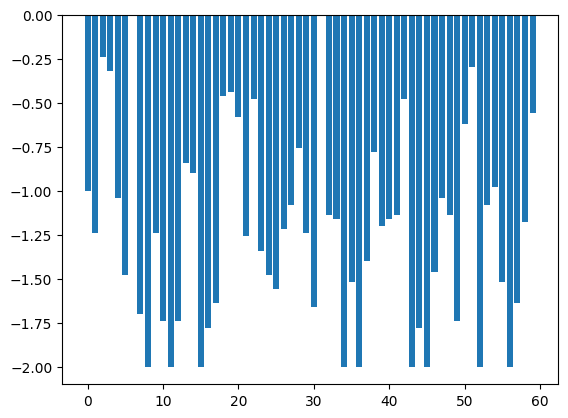

In [126]:
logit_00_contextuality_gen = []
for idx in range(max_llama32):
    data_dict_idx = sentence_order_results_single_gen(idx, llama32)
    logit_00_contextuality_gen.append(calculate_sentence_nc_fraction_single_gen(data_dict_idx))
plt.bar(range(max_llama32), logit_00_contextuality_gen)

<BarContainer object of 60 artists>

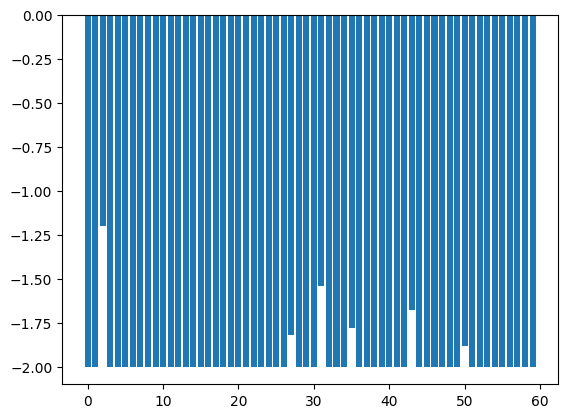

In [127]:
logit_01_contextuality_gen = []
for idx in range(max_llama32):
    data_dict_idx = sentence_order_results_single_gen(idx, llama32, pnoun_order=[0,1])
    logit_01_contextuality_gen.append(calculate_sentence_nc_fraction_single_gen(data_dict_idx))
plt.bar(range(max_llama32), logit_01_contextuality_gen)

<BarContainer object of 60 artists>

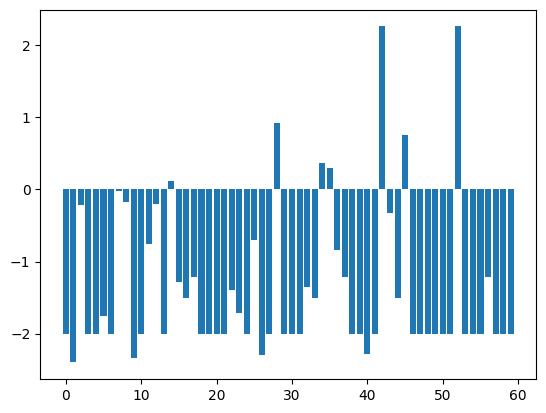

In [128]:
logit_10_contextuality_gen = []
for idx in range(max_llama32):
    data_dict_idx = sentence_order_results_single_gen(idx, llama32, pnoun_order=[1,0])
    logit_10_contextuality_gen.append(calculate_sentence_nc_fraction_single_gen(data_dict_idx))
plt.bar(range(max_llama32), logit_10_contextuality_gen)

<BarContainer object of 60 artists>

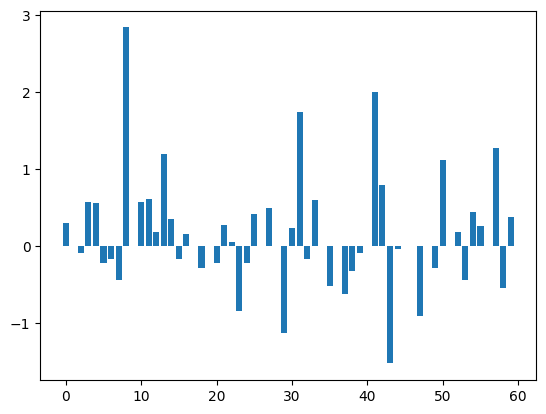

In [129]:
logit_11_contextuality_gen = []
for idx in range(max_llama32):
    data_dict_idx = sentence_order_results_single_gen(idx, llama32, pnoun_order=[1,1])
    logit_11_contextuality_gen.append(calculate_sentence_nc_fraction_single_gen(data_dict_idx))
plt.bar(range(max_llama32), logit_11_contextuality_gen)

In [ ]:
## WHEN THE FIRST SENTENCE IS FEMALE IT GETS FUCKED 

## Llama Generation Results

In [27]:
RESULTS_DIR = DATA_DIR / "processed"

In [29]:
cbd_columns = ['sentence_mfmf', 'sentence_mffm', 'sentence_fmmf', 'sentence_fmfm']

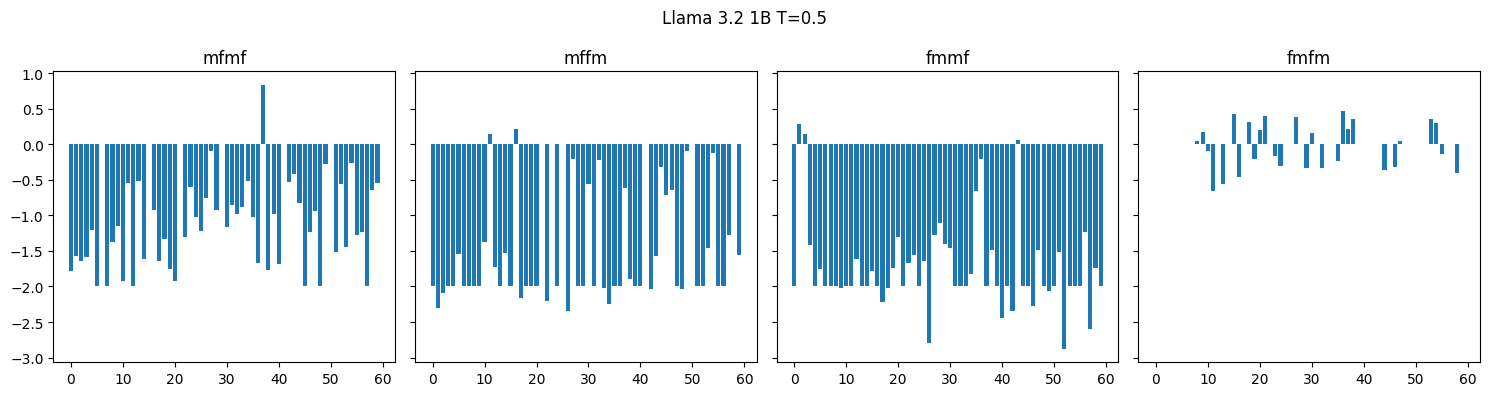

In [35]:
llama321005_results = pd.read_csv(DATA_DIR/"Llama-3.2-1B-Instruct-T0.5.tsv", sep='\t')

fig, axs = plt.subplots(1, 4, figsize=(15, 4), sharey=True)
for n,col in enumerate(cbd_columns):
    axs[n].bar(llama321005_results.index, llama321005_results[col])
    axs[n].set_title(col.split("_")[-1])
    
fig.suptitle("Llama 3.2 1B T=0.5")
plt.tight_layout()

In [ ]:
## WAIT... IS -3 EVEN POSSIBLE ? CAN YOU EVEN GO > -2.0?

# Measuring Contextuality with a Fixed First Pronoun

## No Disaggregating in the First

In [331]:
# Sentence-order contextuality via CBD
def sentence_order_single_dict(idx: int,
                                    model_measurements: list[dict],
                                    pnoun_order: int, # 0 for [m, f], 1 for [f, m]
                                    default_pronoun: int = 1  # 0 for male, 1 for female
                                   ) -> dict:
    """
    Creates a dictionary given a subset of measurements for a single pair of sentences which summarizes the results of
    all runs, separated on the basis of sentence order, filtered for only one pronoun order.

    :param idx: integer index sentence pair
    :param model_measurements: list of Measurement objects (or equivalently structured dictionaries)
    :param pnoun_order: filtered pronoun order--NOTE: this uses default_pronoun indexing 
    :param default_pronoun: pronoun index for probabiity calculations (default = 1 for female)
    :return:
    """
    sentence_measurements = get_index(idx, model_measurements)
    test_measurements = [d for d in sentence_measurements if (d['context']['pnoun_order'][1] == pnoun_order) and 
                        (d['context']['pnoun_order'][0] is not None)]

    data_dict = {'forward': {'fixed_pnoun': [], 'free_pnoun': [], 'pronouns': []},
                 'reverse': {'fixed_pnoun': [], 'free_pnoun': [], 'pronouns': []}}

    for d in test_measurements:
        
        context = d['context']['sent_order'] 
            
        if context == [0, 1]:
            dict_key = 'forward'
            fixed_pnoun = d['context']['pnoun_order'][0]
            try: 
                free_pnoun = d['measurement']['BLANK']
            except TypeError:
                continue
            default_p1 = d['context']['pronouns_1'][default_pronoun]
            default_p2 = d['context']['pronouns_2'][default_pronoun]
        elif context == [1, 0]:
            dict_key = 'reverse'
            fixed_pnoun = d['context']['pnoun_order'][0]
            try: 
                free_pnoun = d['measurement']['BLANK']
            except TypeError:
                continue
            default_p1 = d['context']['pronouns_2'][default_pronoun]
            default_p2 = d['context']['pronouns_1'][default_pronoun]
        else:
            raise AttributeError

        data_dict[dict_key]['fixed_pnoun'].append(fixed_pnoun.lower())
        data_dict[dict_key]['free_pnoun'].append(free_pnoun.lower())
        data_dict[dict_key]['pronouns'] = [default_p1, default_p2]

    return data_dict


Text(0.5, 1.0, 'Generation, [m,f] order')

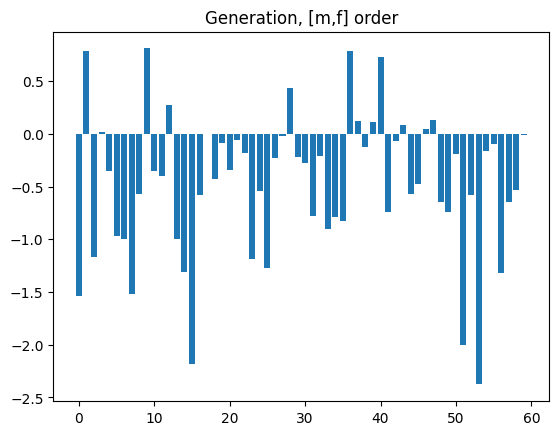

In [332]:
logit_0_contextuality_gen_2 = []
for idx in range(max_llama32):
    data_dict_idx = sentence_order_single_dict(idx, llama32, pnoun_order=0)
    logit_0_contextuality_gen_2.append(calculate_sentence_nc_fraction_single_gen(data_dict_idx))
plt.bar(range(max_llama32), logit_0_contextuality_gen_2)
plt.title('Generation, [m,f] order')

In [333]:
logit_1_contextuality_gen_2 = []
for idx in range(max_llama32):
    data_dict_idx = sentence_order_single_dict(idx, llama32, pnoun_order=1)
    logit_1_contextuality_gen_2.append(calculate_sentence_nc_fraction_single_gen(data_dict_idx))
plt.bar(range(max_llama32), logit_1_contextuality_gen_2)
plt.title('Generation, [f,m] order')

(51, {'forward': {'fixed_pnoun': [], 'free_pnoun': [], 'pronouns': []}, 'reverse': {'fixed_pnoun': [], 'free_pnoun': [], 'pronouns': []}})


ZeroDivisionError: division by zero

## Beliefs, no disaggregating

In [ ]:
def sentence_order_single_internal(idx: int,
                                    model_measurements: list[dict],
                                    pnoun_order: int, # 0 for [m, f], 1 for [f, m]
                                    default_pronoun: int = 1  # 0 for male, 1 for female
                                   ) -> dict:
    """
    Creates a dictionary given a subset of measurements for a single pair of sentences which summarizes the results of
    all runs, separated on the basis of sentence order, filtered for only one pronoun order.

    :param idx: integer index sentence pair
    :param model_measurements: list of Measurement objects (or equivalently structured dictionaries)
    :param pnoun_order: filtered pronoun order--NOTE: this uses default_pronoun indexing 
    :param default_pronoun: pronoun index for probabiity calculations (default = 1 for female)
    :return:
    """
    sentence_measurements = get_index(idx, model_measurements)
    test_measurements = [d for d in sentence_measurements if (d['context']['pnoun_order'][1] == pnoun_order) and 
                        (d['context']['pnoun_order'][0] is not None)]

    data_dict = {'forward': {'fixed_pnoun': [], 'free_pnoun': [], 'pronouns': []},
                 'reverse': {'fixed_pnoun': [], 'free_pnoun': [], 'pronouns': []}}

    for d in test_measurements:
        
        context = d['context']['sent_order'] 
            
        if context == [0, 1]:
            dict_key = 'forward'
            fixed_pnoun = d['context']['pnoun_order'][0]
            free_pnoun = d['logits']
            default_p1 = d['context']['pronouns_1'][default_pronoun]
            default_p2 = d['context']['pronouns_2'][default_pronoun]
        elif context == [1, 0]:
            dict_key = 'reverse'
            fixed_pnoun = d['context']['pnoun_order'][0]
            free_pnoun = d['logits']
            default_p1 = d['context']['pronouns_2'][default_pronoun]
            default_p2 = d['context']['pronouns_1'][default_pronoun]
        else:
            raise AttributeError

        data_dict[dict_key]['fixed_pnoun'].append(fixed_pnoun.lower())
        data_dict[dict_key]['free_pnoun'].append(free_pnoun)
        data_dict[dict_key]['pronouns'] = [default_p1, default_p2]

    return data_dict

In [ ]:
logit_0_contextuality = []
for idx in range(max_llama32):
    data_dict_idx = sentence_order_single_internal(idx, llama32, 0)
    logit_0_contextuality.append(calculate_sentence_nc_fraction_internal(data_dict_idx))
plt.bar(range(max_llama32), logit_0_contextuality)
plt.title('Model, [m,f] order')

In [ ]:
logit_1_contextuality = []
for idx in range(max_llama32):
    data_dict_idx = sentence_order_single_internal(idx, llama32, 1)
    logit_1_contextuality.append(calculate_sentence_nc_fraction_internal(data_dict_idx))
plt.bar(range(max_llama32), logit_1_contextuality)
plt.title('Model, [f,m] order')

ValueError: shape mismatch: objects cannot be broadcast to a single shape.  Mismatch is between arg 0 with shape (60,) and arg 1 with shape (51,).

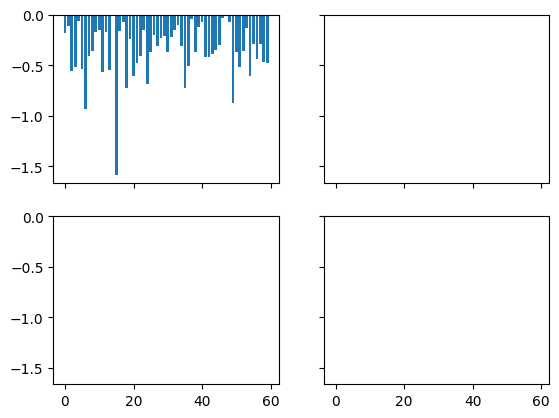

In [330]:
fig, axs = plt.subplots(2,2, sharey=True, sharex=True)
dist_bins = np.linspace(0,2,21)
axs[0,0].bar(range(max_llama32), logit_0_contextuality)
axs[0,1].bar(range(max_llama32), logit_1_contextuality)
axs[1,0].bar(range(max_llama32), logit_0_contextuality_gen_2)
axs[1,1].bar(range(max_llama32), logit_1_contextuality_gen_2)

axs[0,0].set_title('Male Pronoun First', fontsize=10)
axs[0,1].set_title('Female Pronoun First', fontsize=10)
axs[0,0].set_ylabel(r'Model $\Delta C$', )
axs[1,0].set_ylabel(r'Generation $\Delta C$')

fig.suptitle('Contextuality in Llama 3.2 1B')
plt.tight_layout()

In [252]:
qwen_0_contextuality_gen_2 = []
for idx in range(max_qwen15):
    data_dict_idx = sentence_order_single_dict(idx, qwen15, pnoun_order=0)
    qwen_0_contextuality_gen_2.append(calculate_sentence_nc_fraction_single_gen(data_dict_idx))
#plt.bar(range(max_qwen15), qwen_0_contextuality_gen_2)
#plt.title('Generation, [m,f] order')
qwen_1_contextuality_gen_2 = []
for idx in range(max_qwen15):
    data_dict_idx = sentence_order_single_dict(idx, qwen15, pnoun_order=1)
    qwen_1_contextuality_gen_2.append(calculate_sentence_nc_fraction_single_gen(data_dict_idx))
#plt.bar(range(max_qwen15), qwen_1_contextuality_gen_2)
#plt.title('Generation, [m,f] order')

qwen_0_contextuality = []
for idx in range(max_qwen15):
    data_dict_idx = sentence_order_single_internal(idx, qwen15, 0)
    qwen_0_contextuality.append(calculate_sentence_nc_fraction_internal(data_dict_idx))
#plt.bar(range(max_qwen15), qwen_0_contextuality)
#plt.title('Model, [m,f] order')
qwen_1_contextuality = []
for idx in range(max_qwen15):
    data_dict_idx = sentence_order_single_internal(idx, qwen15, 1)
    qwen_1_contextuality.append(calculate_sentence_nc_fraction_internal(data_dict_idx))
#plt.bar(range(max_qwen15), qwen_1_contextuality)
#plt.title('Model, [m,f] order')

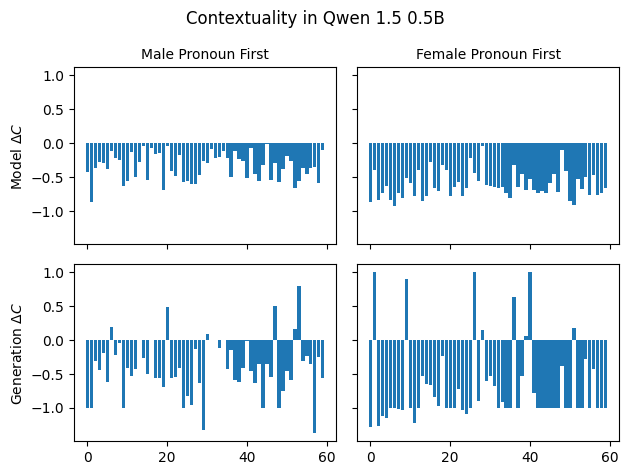

In [253]:
fig, axs = plt.subplots(2,2, sharey=True, sharex=True)
dist_bins = np.linspace(0,2,21)

axs[0,0].bar(range(max_qwen15), qwen_0_contextuality)
axs[0,1].bar(range(max_qwen15), qwen_1_contextuality)
axs[1,0].bar(range(max_qwen15), qwen_0_contextuality_gen_2)
axs[1,1].bar(range(max_qwen15), qwen_1_contextuality_gen_2)


axs[0,0].set_title('Male Pronoun First', fontsize=10)
axs[0,1].set_title('Female Pronoun First', fontsize=10)
axs[0,0].set_ylabel(r'Model $\Delta C$', )
axs[1,0].set_ylabel(r'Generation $\Delta C$')

fig.suptitle('Contextuality in Qwen 1.5 0.5B')
plt.tight_layout()

In [160]:
PHI_PATH = DATA_DIR / "one_pronoun_measurements_Phi-4-mini-instruct_0.5.ndjson"
phi4 = load_ndjson(PHI_PATH)
max_phi=max([d['index'] for d in phi4])

In [225]:
phi_0_contextuality_gen_2 = []
for idx in range(max_phi):
    data_dict_idx = sentence_order_single_dict(idx, phi4, pnoun_order=0)
    phi_0_contextuality_gen_2.append(calculate_sentence_nc_fraction_single_gen(data_dict_idx))

phi_1_contextuality_gen_2 = []
for idx in range(max_phi):
    data_dict_idx = sentence_order_single_dict(idx, phi4, pnoun_order=1)
    phi_1_contextuality_gen_2.append(calculate_sentence_nc_fraction_single_gen(data_dict_idx))


phi_0_contextuality = []
for idx in range(max_phi):
    data_dict_idx = sentence_order_single_internal(idx, phi4, 0)
    phi_0_contextuality.append(calculate_sentence_nc_fraction_internal(data_dict_idx))

phi_1_contextuality = []
for idx in range(max_phi):
    data_dict_idx = sentence_order_single_internal(idx, phi4, 1)
    phi_1_contextuality.append(calculate_sentence_nc_fraction_internal(data_dict_idx))


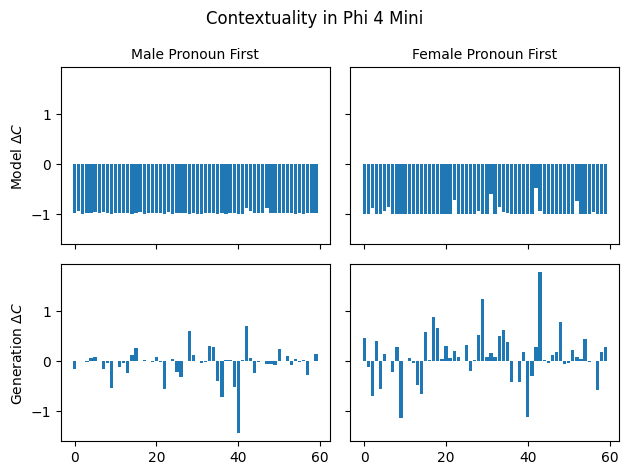

In [162]:
fig, axs = plt.subplots(2,2, sharey=True, sharex=True)
dist_bins = np.linspace(0,2,21)

axs[0,0].bar(range(max_qwen15), qwen_0_contextuality)
axs[0,1].bar(range(max_qwen15), qwen_1_contextuality)
axs[1,0].bar(range(max_qwen15), qwen_0_contextuality_gen_2)
axs[1,1].bar(range(max_qwen15), qwen_1_contextuality_gen_2)


axs[0,0].set_title('Male Pronoun First', fontsize=10)
axs[0,1].set_title('Female Pronoun First', fontsize=10)
axs[0,0].set_ylabel(r'Model $\Delta C$', )
axs[1,0].set_ylabel(r'Generation $\Delta C$')

fig.suptitle('Contextuality in Phi 4 Mini')
plt.tight_layout()

In [249]:
GPT_PATH = DATA_DIR / "one_pronoun_measurements_gpt-oss-20b_0.5.ndjson"
gpt = load_ndjson(GPT_PATH)
max_gpt=max([d['index'] for d in gpt])

In [250]:
gpt_0_contextuality_gen_2 = []
for idx in range(max_gpt):
    data_dict_idx = sentence_order_single_dict(idx, gpt, pnoun_order=0)
    gpt_0_contextuality_gen_2.append(calculate_sentence_nc_fraction_single_gen(data_dict_idx))

gpt_1_contextuality_gen_2 = []
for idx in range(max_gpt):
    data_dict_idx = sentence_order_single_dict(idx, gpt, pnoun_order=1)
    gpt_1_contextuality_gen_2.append(calculate_sentence_nc_fraction_single_gen(data_dict_idx))


gpt_0_contextuality = []
for idx in range(max_gpt):
    data_dict_idx = sentence_order_single_internal(idx, gpt, 0)
    gpt_0_contextuality.append(calculate_sentence_nc_fraction_internal(data_dict_idx))

gpt_1_contextuality = []
for idx in range(max_gpt):
    data_dict_idx = sentence_order_single_internal(idx, gpt, 1)
    gpt_1_contextuality.append(calculate_sentence_nc_fraction_internal(data_dict_idx))


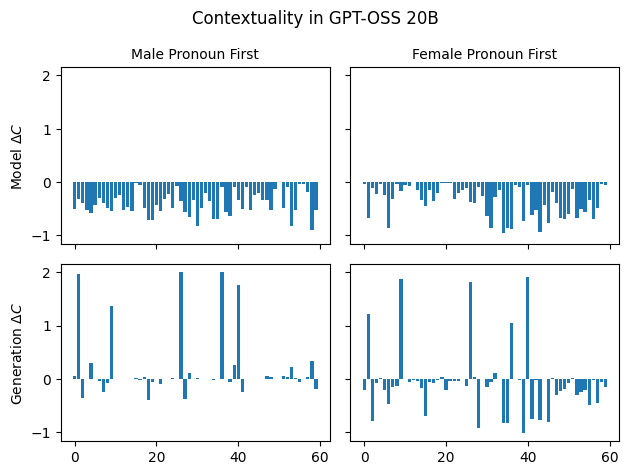

In [251]:
fig, axs = plt.subplots(2,2, sharey=True, sharex=True)
dist_bins = np.linspace(0,2,21)

axs[0,0].bar(range(max_gpt), gpt_0_contextuality)
axs[0,1].bar(range(max_gpt), gpt_1_contextuality)
axs[1,0].bar(range(max_gpt), gpt_0_contextuality_gen_2)
axs[1,1].bar(range(max_gpt), gpt_1_contextuality_gen_2)


axs[0,0].set_title('Male Pronoun First', fontsize=10)
axs[0,1].set_title('Female Pronoun First', fontsize=10)
axs[0,0].set_ylabel(r'Model $\Delta C$', )
axs[1,0].set_ylabel(r'Generation $\Delta C$')

fig.suptitle('Contextuality in GPT-OSS 20B')
plt.tight_layout()

# Stereotype Alignment

In [44]:
wino_pairs = pd.read_csv('../../wino_pairs.tsv', sep='\t')
wino_pairs.head()

,template_1,differences_1,referent_1,template_2,differences_2,referent_2
0,The technician told the customer that BLANK co...,"['he', 'she']",customer,The technician told the customer that BLANK ha...,"['he', 'she']",technician
1,The taxpayer met with the accountant to get he...,"['his', 'her']",customer,The taxpayer met with the accountant to find o...,"['he', 'she']",technician
2,The supervisor gave the employee feedback on B...,"['his', 'her']",customer,The employee gave the supervisor feedback on B...,"['his', 'her']",technician
3,The engineer informed the client that BLANK wo...,"['he', 'she']",customer,The engineer informed the client that BLANK wo...,"['he', 'she']",technician
4,The worker told the pedestrian that BLANK shou...,"['he', 'she']",customer,The worker told the pedestrian that BLANK was ...,"['he', 'she']",technician


In [43]:
job_stats = pd.read_csv('../../occupations-stats.tsv', sep='\t')
job_stats.head()

,occupation,bergsma_pct_female,bls_pct_female,bls_year
0,technician,9.42,40.34,2015
1,accountant,9.26,59.70,2015
2,supervisor,36.02,38.64,2015
3,engineer,1.99,10.72,2015
4,worker,13.43,37.92,2016


In [48]:
[5500]

{'index': 3,
 'context': {'sent_order': [0, 1],
  'pnoun_order': ['she', 1],
  'sentence_1': 'The engineer informed the client that she would need more time to complete the project.',
  'sentence_2': 'The engineer informed the client that BLANK would need to make all future payments on time.',
  'pronouns_1': ['he', 'she'],
  'pronouns_2': ['he', 'she']},
 'measurement': {'BLANK': 'she'},
 'probabilities': None,
 'logits': [6.09765625, 7.16796875]}

## Qwen

In [211]:
QWEN15_PATH = DATA_DIR / "one_pronoun_measurements_Qwen1.5-0.5B-Chat_0.501.ndjson"
qwen15 = load_ndjson(QWEN15_PATH)
max_qwen15 =max([d['index'] for d in qwen15])

In [215]:
def belief_generation_pairs(data,
                          max_idx):

    """
    """

    bel_gen_pairs = []

    for idx in range(max_idx):
        d1 = get_single_sentences(get_sent_order([0,1], get_index(idx, data)))
        d2 = get_single_sentences(get_sent_order([1,0], get_index(idx, data)))

        bel_gen_pairs.append((get_internal_probs(d1)[1], get_generation_probs(d1)[1]))
        bel_gen_pairs.append((get_internal_probs(d2)[1], get_generation_probs(d2)[1]))

    return bel_gen_pairs

/tmp/ipykernel_3224490/627583355.py:24: RuntimeWarning: invalid value encountered in divide
  generation_probs = np.array(list(generation_counter_clean.values()))/num_valid_measurements


Text(0, 0.5, 'Empirical Generation Probability')

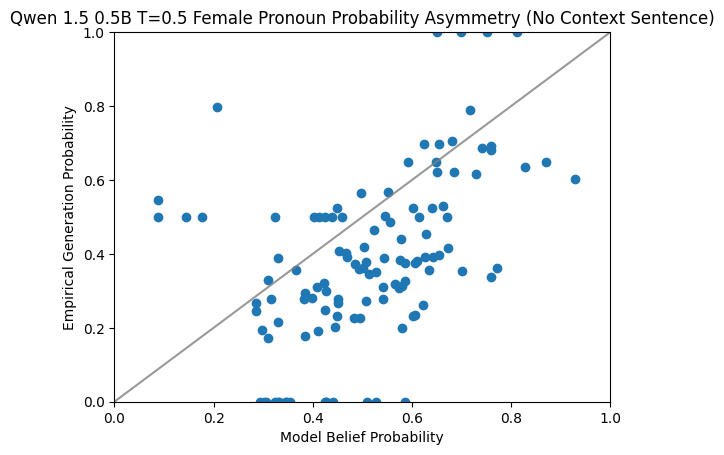

In [224]:
internal_generated_qwen15 = belief_generation_pairs(qwen15, max_qwen15)
    
plt.scatter([i[0] for i in internal_generated_qwen15], 
           [i[1] for i in internal_generated_qwen15])
plt.plot(np.linspace(0,1,20), np.linspace(0,1,20), color='grey', alpha=0.8)

plt.ylim(0,1)
plt.xlim(0,1)
plt.title('Qwen 1.5 0.5B T=0.5 Female Pronoun Probability Asymmetry (No Context Sentence)')
plt.xlabel('Model Belief Probability')
plt.ylabel('Empirical Generation Probability')

In [217]:
def belief_generation_distance(data,
                              max_idx):

    bel_gen_distances = []
    for idx in range(max_idx):
        d1 = get_single_sentences(get_sent_order([0,1], get_index(idx, data)))
        d2 = get_single_sentences(get_sent_order([1,0], get_index(idx, data)))
        
        bel_gen_distances.append(get_generation_logit_distortion(d1))
        bel_gen_distances.append(get_generation_logit_distortion(d2))

    return bel_gen_distances

/tmp/ipykernel_3224490/627583355.py:24: RuntimeWarning: invalid value encountered in divide
  generation_probs = np.array(list(generation_counter_clean.values()))/num_valid_measurements


Text(0.5, 1.0, 'Distance Distribution Qwen 1.5 0.5B')

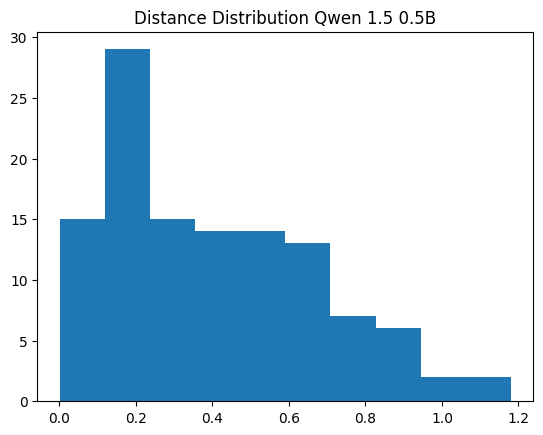

In [218]:
bel_gen_dist_qwen15 = belief_generation_distance(qwen15, max_qwen15)
plt.hist(bel_gen_dist_qwen15, bins=10)
plt.title('Distance Distribution Qwen 1.5 0.5B')

In [219]:
def context_distances(data, max_idx):

    """
    """
    
    sent_orders = [[0,1], [1,0]]
    
    m_first_logit_changes = []
    f_first_logit_changes = []
    m_first_gen_changes = []
    f_first_gen_changes = []

    for idx in range(max_idx):
        for order in sent_orders:
            none_sentence = get_single_sentences(get_sent_order(order, get_index(idx, data)))
            
            m_filled_sentence = get_filled_pnoun(0, get_sent_order(order, get_index(idx, data)))
            m_first_logit_changes.append(distance.cityblock(
                get_internal_probs(none_sentence), 
                get_internal_probs(m_filled_sentence)))
            m_first_gen_changes.append(distance.cityblock(
                get_generation_probs(none_sentence), 
                get_generation_probs(m_filled_sentence)))

            f_filled_sentence = get_filled_pnoun(1, get_sent_order(order, get_index(idx, data)))
            f_first_logit_changes.append(distance.cityblock(
                get_internal_probs(none_sentence), 
                get_internal_probs(f_filled_sentence)))

            f_first_gen_changes.append(distance.cityblock(
                get_generation_probs(none_sentence), 
                get_generation_probs(f_filled_sentence)))


    return m_first_logit_changes, f_first_logit_changes, m_first_gen_changes, f_first_gen_changes

/tmp/ipykernel_3224490/627583355.py:24: RuntimeWarning: invalid value encountered in divide
  generation_probs = np.array(list(generation_counter_clean.values()))/num_valid_measurements


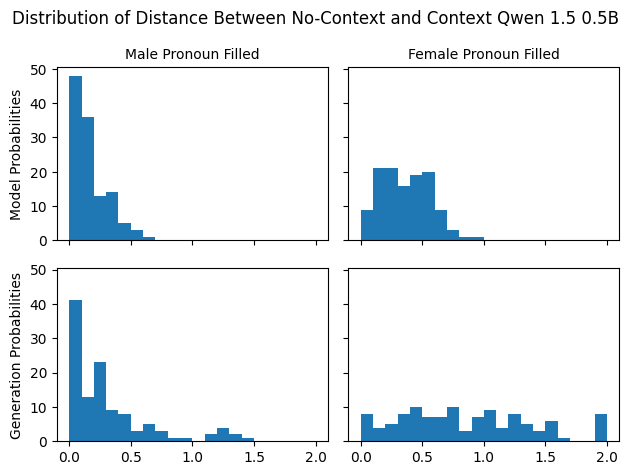

In [220]:
# Can be greater than 80 because we actually have 120 sentences

qwen_m_first_logit_changes, qwen_f_first_logit_changes, qwen_m_first_gen_changes, qwen_f_first_gen_changes = context_distances(qwen15, 
                                                                                                                               max_qwen15)

fig, axs = plt.subplots(2,2, sharey=True, sharex=True)
dist_bins = np.linspace(0,2,21)
axs[0,0].hist(qwen_m_first_logit_changes, bins=dist_bins)
axs[0,1].hist(qwen_f_first_logit_changes, bins=dist_bins)
axs[1,0].hist(qwen_m_first_gen_changes, bins=dist_bins)
axs[1,1].hist(qwen_f_first_gen_changes, bins=dist_bins)

axs[0,0].set_title('Male Pronoun Filled', fontsize=10)
axs[0,1].set_title('Female Pronoun Filled', fontsize=10)
axs[0,0].set_ylabel('Model Probabilities', )
axs[1,0].set_ylabel('Generation Probabilities')

fig.suptitle('Distribution of Distance Between No-Context and Context Qwen 1.5 0.5B')
plt.tight_layout()

In [221]:
def order_bias_context_free(data, max_idx, mode):

    fwd_none_model = []
    bwd_none_model = []
    
    for idx in range(max_idx):
        for order in sent_orders:
            fwd = get_pnoun_order(0, get_single_sentences(get_sent_order(order, get_index(idx, data))))
            bwd = get_pnoun_order(1, get_single_sentences(get_sent_order(order, get_index(idx, data))))
            
            if mode == 'internal':
                fwd_none_model.append(get_internal_probs(fwd)[1])
                bwd_none_model.append(get_internal_probs(bwd)[1])
            elif mode == 'generation':
                fwd_none_model.append(get_generation_probs(fwd)[1])
                bwd_none_model.append(get_generation_probs(bwd)[1])
            else:
                raise ValueError("mode parameter must be either 'internal' or 'generation'")

    return fwd_none_model, bwd_none_model

Text(0.5, 1.0, 'Qwen 1.5 0.5B Model Probabilities')

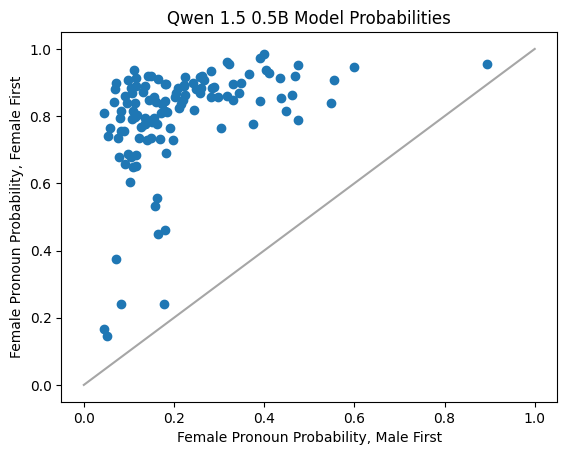

In [222]:
qwen_fwd_none_model_internal, qwen_bwd_none_model_internal = order_bias_context_free(qwen15, max_qwen15, 'internal')
        
plt.scatter(qwen_fwd_none_model_internal, qwen_bwd_none_model_internal)
plt.plot(np.linspace(0,1,10), np.linspace(0,1,10), marker=None, color='gray', alpha=0.7)
plt.xlabel('Female Pronoun Probability, Male First')
plt.ylabel('Female Pronoun Probability, Female First')
plt.title('Qwen 1.5 0.5B Model Probabilities')

/tmp/ipykernel_3224490/627583355.py:24: RuntimeWarning: invalid value encountered in divide
  generation_probs = np.array(list(generation_counter_clean.values()))/num_valid_measurements


Text(0.5, 1.0, 'Qwen 1.5 0.5B Generation Probabilities')

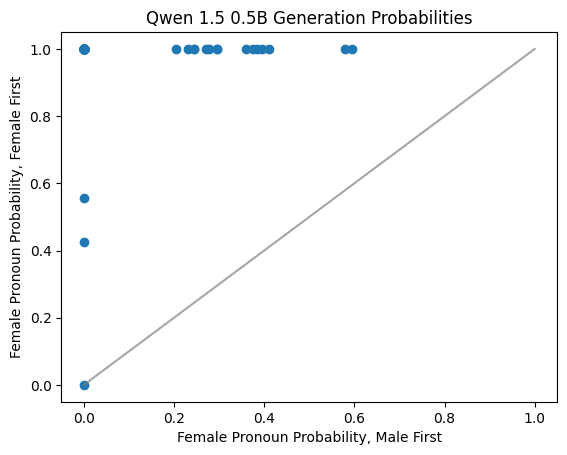

In [223]:
qwen_fwd_none_model_gen, qwen_bwd_none_model_gen= order_bias_context_free(qwen15, max_qwen15, 'generation')
        
plt.scatter(qwen_fwd_none_model_gen, qwen_bwd_none_model_gen)
plt.plot(np.linspace(0,1,10), np.linspace(0,1,10), marker=None, color='gray', alpha=0.7)
plt.xlabel('Female Pronoun Probability, Male First')
plt.ylabel('Female Pronoun Probability, Female First')
plt.title('Qwen 1.5 0.5B Generation Probabilities')

# GPT OSS Stats

Text(0, 0.5, 'Empirical Generation Probability')

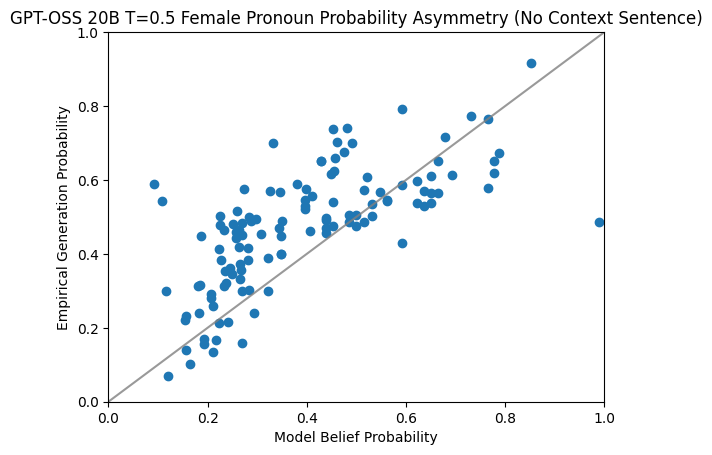

In [200]:
internal_generated_gpt = belief_generation_pairs(gpt, max_gpt)
    
plt.scatter([i[0] for i in internal_generated_gpt], 
           [i[1] for i in internal_generated_gpt])
plt.plot(np.linspace(0,1,20), np.linspace(0,1,20), color='grey', alpha=0.8)

plt.ylim(0,1)
plt.xlim(0,1)
plt.title('GPT-OSS 20B T=0.5 Female Pronoun Probability Asymmetry (No Context Sentence)')
plt.xlabel('Model Belief Probability')
plt.ylabel('Empirical Generation Probability')

Text(0.5, 1.0, 'Distance Distribution GPT-OSS 20B')

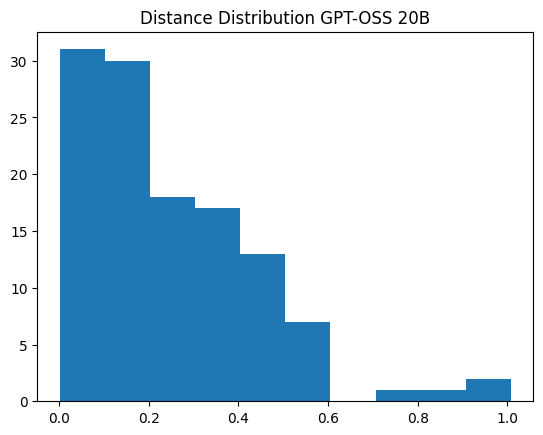

In [171]:
bel_gen_dist_gpt = belief_generation_distance(gpt, max_gpt)
plt.hist(bel_gen_dist_gpt, bins=10)
plt.title('Distance Distribution GPT-OSS 20B')

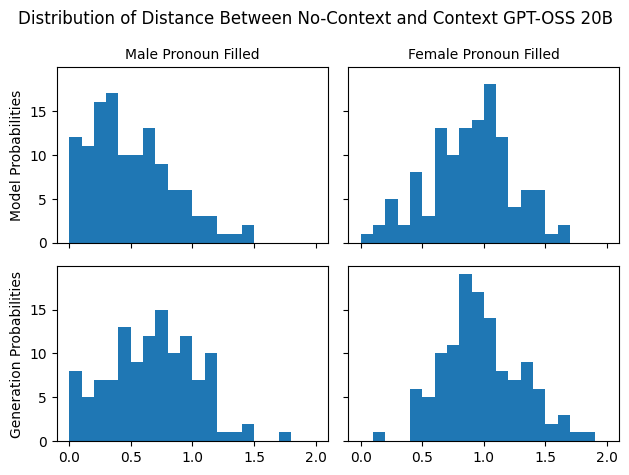

In [172]:
# Can be greater than 80 because we actually have 120 sentences

gpt_m_first_logit_changes, gpt_f_first_logit_changes, gpt_m_first_gen_changes, gpt_f_first_gen_changes = context_distances(gpt, 
                                                                                                                               max_gpt)

fig, axs = plt.subplots(2,2, sharey=True, sharex=True)
dist_bins = np.linspace(0,2,21)
axs[0,0].hist(gpt_m_first_logit_changes, bins=dist_bins)
axs[0,1].hist(gpt_f_first_logit_changes, bins=dist_bins)
axs[1,0].hist(gpt_m_first_gen_changes, bins=dist_bins)
axs[1,1].hist(gpt_f_first_gen_changes, bins=dist_bins)

axs[0,0].set_title('Male Pronoun Filled', fontsize=10)
axs[0,1].set_title('Female Pronoun Filled', fontsize=10)
axs[0,0].set_ylabel('Model Probabilities', )
axs[1,0].set_ylabel('Generation Probabilities')

fig.suptitle('Distribution of Distance Between No-Context and Context GPT-OSS 20B')
plt.tight_layout()

Text(0.5, 1.0, 'GPT-OSS 20B Model Probabilities')

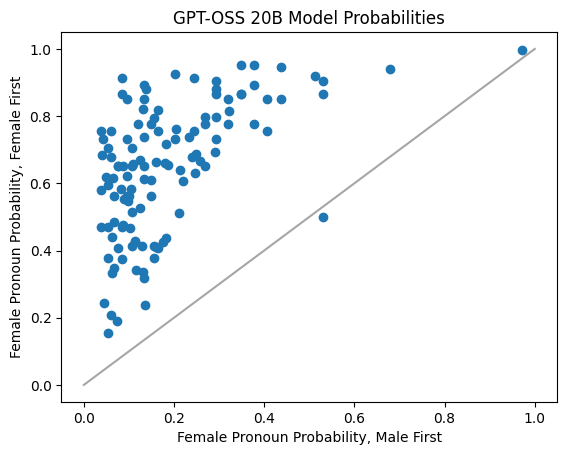

In [173]:
gpt_fwd_none_model_internal, gpt_bwd_none_model_internal = order_bias_context_free(gpt, max_gpt, 'internal')
        
plt.scatter(gpt_fwd_none_model_internal, gpt_bwd_none_model_internal)
plt.plot(np.linspace(0,1,10), np.linspace(0,1,10), marker=None, color='gray', alpha=0.7)
plt.xlabel('Female Pronoun Probability, Male First')
plt.ylabel('Female Pronoun Probability, Female First')
plt.title('GPT-OSS 20B Model Probabilities')

Text(0.5, 1.0, 'GPT-OSS 20B Generation Probabilities')

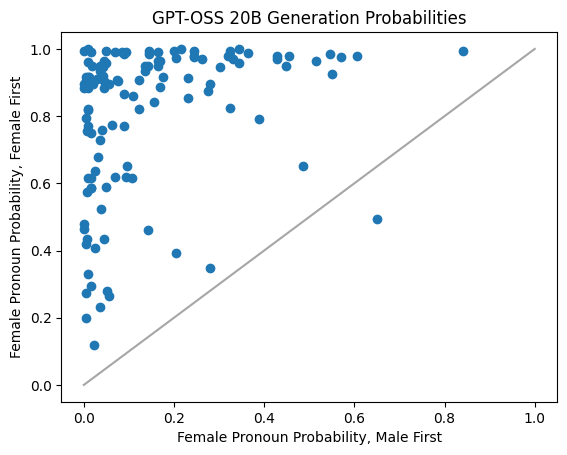

In [174]:
gpt_fwd_none_model_gen, gpt_bwd_none_model_gen= order_bias_context_free(gpt, max_gpt, 'generation')
        
plt.scatter(gpt_fwd_none_model_gen, gpt_bwd_none_model_gen)
plt.plot(np.linspace(0,1,10), np.linspace(0,1,10), marker=None, color='gray', alpha=0.7)
plt.xlabel('Female Pronoun Probability, Male First')
plt.ylabel('Female Pronoun Probability, Female First')
plt.title('GPT-OSS 20B Generation Probabilities')

# Contextual Pairs

In [ ]:
gen_contextuality_results = {
    'llama': {'mfirst': logit_0_contextuality_gen_2, 'ffirst':logit_1_contextuality_gen_2},
    'qwen': {'mfirst': qwen_0_contextuality_gen_2, 'ffirst':qwen_1_contextuality_gen_2},
    'gpt': {'mfirst': gpt_0_contextuality_gen_2, 'ffirst':gpt_1_contextuality_gen_2}
}

In [228]:
contextuality_results = pd.DataFrame(data={
    "llama32_mfirst": logit_0_contextuality_gen_2,
    "llama32_ffirst": logit_1_contextuality_gen_2,
    "qwen_mfirst": qwen_0_contextuality_gen_2,
    "qwen_ffirst": qwen_1_contextuality_gen_2,
    "gpt_mfirst": gpt_0_contextuality_gen_2,
    "gpt_ffirst": gpt_1_contextuality_gen_2
})

In [239]:
contextuality_results.loc[contextuality_results[contextuality_results > 0].any(axis=1)]

(46, 6)

# Pronoun Order Contextuality

In [277]:
def pronoun_context_array(
        index: int,
        data: list[dict] | list[dict],
        forward: bool = True
) -> np.ndarray:
    """
    Given data in the form of a list of Measurement objects (see collect_sequential.py) OR equivalent dictionaries,
    this function outputs the measurement scenario array, as described in sheaf-contextual approaches to contextuality.

    :param index: integer index sentence pair
    :param data: list of Measurement objects (or equivalently structured dictionaries)
    :param forward: Whether sentences should be in forward or reverse order (default=True)
    :return: measurement scenario array
    """
    # Constants
    female_pnouns = {'she', 'her', 'hers'}
    male_pnouns = {'he', 'him', 'his'}

    def pnoun_index_map(pnoun):
        if pnoun in male_pnouns:
            return 0
        elif pnoun in female_pnouns:
            return 1
        else:
            raise AttributeError(f"{pnoun} not in pronoun list")
    
    orientations = [[0, 0], [0, 1], [1, 0], [1, 1]]

    # Sentence order control
    if forward == True:
        sentence_order = [0, 1]
    else:
        sentence_order = [1, 0]

    # Loading data and creating empty dictionary
    measurement_data = get_sent_order(sentence_order, get_index(index, data))
    measurement_data = [m for m in measurement_data if m['context']['sentence_1'] is not None]
    measurement_dict = {tuple(o): {tuple(o): 0 for o in orientations} for o in orientations}
    print(f"Checking contextuality on basis of {len(measurement_data)} measurements.")

    # Collecting empirical probabilities
    for d in measurement_data:
        orientation = (pnoun_index_map(d['context']['pnoun_order'][0]), d['context']['pnoun_order'][1])
        measurement = d['measurement']['BLANK']
        encoded_m = (pnoun_index_map(d['context']['pnoun_order'][0]), measurement in female_pnouns)
        measurement_dict[orientation][encoded_m] += 1

    # Converting dictionary of dictionaries to array
    arr_list = []
    for outcome_dict in measurement_dict.values():
        ctx_total = sum(outcome_dict.values())
        ctx_list = []
        for val in outcome_dict.values():
            try:
                ctx_list.append(val / ctx_total)
            except ZeroDivisionError:
                ctx_list.append(0)

        arr_list.append(ctx_list)
    arr = np.array(arr_list)

    return arr

def calculate_pronouns_nc_fraction(
        arr: np.ndarray
) -> float:

    """
    Calculates the noncontextual fraction, as per Dzhafarov for a 4-cycle situation with data structured as a list of
    Measurement objects.

    :param arr: MeasurementScenario.scenario.values array
    """

    correlations = []
    vs = []
    ws = []

    for row in arr:
        # marginals
        dzhafarov_arr = row.reshape(2,2)
        px = np.sum(dzhafarov_arr, axis=1)[1] # indexing on the basis of index 1 (female pronoun probability)
        py = np.sum(dzhafarov_arr, axis=0)[1]
        pxy = dzhafarov_arr[1,1]

        V1 = cbd_expectation(px)
        W2 = cbd_expectation(py)
        V1W2 = cbd_correlation(px,py,pxy)

        correlations.append(V1W2)
        vs.append(V1)
        ws.append(W2)

    # Calculating the S1 term
    s1_term = cbd_s1_4cycle(*correlations)

    # Calculating the sum of differences
    rotated_ws = [ws[-1]]+ws[:-1]
    sum_term = np.sum([abs(v-w) for v,w in zip(vs,rotated_ws)])

    delta_c = s1_term - 2 - sum_term

    return delta_c


In [280]:
def cbd_expectation(px: float):

    """
    Returns the expectation value of a random variable, given its marginal probability (as per Dzhafarov)
    :param px: marginal probability
    :return: expectation value
    """
    return 2*px - 1

def cbd_correlation(px: float,
                    py: float,
                    pxy: float):
    """
    Returns the correlation of two random variables, given their marginals and joint (as per Dzhafarov)
    :param px: marginal probability of X
    :param py: marginal probability of Y
    :param pxy: joint probability
    :return:
    """
    return 4*pxy - 2*px - 2*py + 1

def cbd_s1_4cycle(w,x,y,z):
    term1 = abs(w+x+y-z)
    term2 = abs(w+x-y-z)
    term3 = abs(w-x+y+z)
    term4 = abs(-w+x+y+z)
    return max(term1,term2,term3,term4)

In [283]:
for idx in range(60):
    print(calculate_pronouns_nc_fraction(pronoun_context_array(idx, llama32)))

Checking contextuality on basis of 400 measurements.
-4.720000000000001
Checking contextuality on basis of 400 measurements.
-4.0
Checking contextuality on basis of 400 measurements.
-4.0
Checking contextuality on basis of 400 measurements.
-2.5999999999999996
Checking contextuality on basis of 400 measurements.
-4.0
Checking contextuality on basis of 400 measurements.
-2.2799999999999994
Checking contextuality on basis of 400 measurements.
-1.2000000000000002
Checking contextuality on basis of 400 measurements.
-4.0
Checking contextuality on basis of 400 measurements.
-3.6799999999999997
Checking contextuality on basis of 400 measurements.
-4.0
Checking contextuality on basis of 400 measurements.
-4.0
Checking contextuality on basis of 400 measurements.
-4.0
Checking contextuality on basis of 400 measurements.
-4.0
Checking contextuality on basis of 400 measurements.
-4.0
Checking contextuality on basis of 400 measurements.
-4.0
Checking contextuality on basis of 400 measurements.
-4.

# Loading the Gendered Statistics

In [117]:
RAW_DATA_DIR = DATA_DIR.parent / "raw"

In [118]:
occ_stats_df = pd.read_csv(RAW_DATA_DIR / "occupations-stats.tsv", sep='\t')

In [285]:
pd.read_csv(RAW_DATA_DIR / "templates.tsv", sep='\t')

,occupation(0),other-participant(1),answer,sentence
0,technician,customer,1,The $OCCUPATION told the $PARTICIPANT that $NO...
1,technician,customer,0,The $OCCUPATION told the $PARTICIPANT that $NO...
2,accountant,taxpayer,1,The $PARTICIPANT met with the $OCCUPATION to g...
3,accountant,taxpayer,0,The $PARTICIPANT met with the $OCCUPATION to f...
4,supervisor,employee,1,The $OCCUPATION gave the $PARTICIPANT feedback...
...,...,...,...,...
115,doctor,patient,0,The $OCCUPATION told the $PARTICIPANT that $NO...
116,firefighter,child,1,The $OCCUPATION had to rescue the $PARTICIPANT...
117,firefighter,child,0,The $OCCUPATION had to rescue the $PARTICIPANT...
118,secretary,visitor,0,The $OCCUPATION asked the $PARTICIPANT to sign...


In [295]:
from datetime import datetime
f"{datetime.now().strftime('%H%M%d%m%y')}"

'1347050925'

In [284]:
pd.read_csv(RAW_DATA_DIR / "data/new_templates.tsv", sep='\t')

,occupation(0),other-participant(1),answer,pronoun_type,template,single_version
0,technician,customer,1,$NOM_PRONOUN,The $OCCUPATION told the $PARTICIPANT that $NO...,The $PARTICIPANT was told that $NOM_PRONOUN co...
1,technician,customer,0,$NOM_PRONOUN,The $OCCUPATION told the $PARTICIPANT that $NO...,The $OCCUPATION said that $NOM_PRONOUN had com...
2,technician,customer,1,$ACC_PRONOUN,The $OCCUPATION had to call the $PARTICIPANT f...,The $PARTICIPANT received a call for $ACC_PRON...
3,technician,customer,0,$ACC_PRONOUN,The $OCCUPATION had to call the $PARTICIPANT f...,The $OCCUPATION called for $ACC_PRONOUN to con...
4,technician,customer,1,$POSS_PRONOUN,The $PARTICIPANT told the $OCCUPATION that $PO...,The $PARTICIPANT said that $POSS_PRONOUN fridg...
...,...,...,...,...,...,...
355,secretary,visitor,1,$NOM_PRONOUN,The $OCCUPATION asked the $PARTICIPANT to sign...,The $PARTICIPANT was asked to sign in so that ...
356,secretary,visitor,0,$ACC_PRONOUN,The $OCCUPATION requested the name of the $PAR...,The $OCCUPATION needed information for $ACC_PR...
357,secretary,visitor,1,$ACC_PRONOUN,The $OCCUPATION requested the name of the $PAR...,The $PARTICIPANT needed to provide information...
358,secretary,visitor,0,$POSS_PRONOUN,The $OCCUPATION informed the $PARTICIPANT that...,The $OCCUPATION said that $POSS_PRONOUN boss w...


In [297]:
INTERIM_DATA_DIR = DATA_DIR.parent / "interim"
pd.read_csv(INTERIM_DATA_DIR / "winopron_pairs.tsv", sep='\t')

,template_1,differences_1,referent_1,template_2,differences_2,referent_2
0,The technician told the customer that BLANK co...,"['he', 'she']",customer,The technician told the customer that BLANK ha...,"['he', 'she']",technician
1,The technician had to call the customer for BL...,"['him', 'her']",customer,The technician had to call the customer for BL...,"['him', 'her']",technician
2,The customer told the technician that BLANK fr...,"['his', 'her']",customer,The customer told the technician that BLANK ch...,"['his', 'her']",technician
3,The taxpayer met with the accountant to find o...,"['he', 'she']",taxpayer,The taxpayer met with the accountant to find o...,"['he', 'she']",accountant
4,The taxpayer met with the accountant for BLANK...,"['him', 'her']",taxpayer,The taxpayer met with the accountant for BLANK...,"['him', 'her']",accountant
...,...,...,...,...,...,...
176,The firefighter told the child that BLANK tedd...,"['his', 'her']",child,The firefighter told the child that BLANK job ...,"['his', 'her']",firefighter
177,The secretary asked the visitor to sign in so ...,"['he', 'she']",visitor,The secretary asked the visitor to sign in so ...,"['he', 'she']",secretary
178,The secretary requested the name of the visito...,"['him', 'her']",visitor,The secretary requested the name of the visito...,"['him', 'her']",secretary
179,The secretary informed the visitor that BLANK ...,"['his', 'her']",visitor,The secretary informed the visitor that BLANK ...,"['his', 'her']",secretary
